Charge des donnees

Les bibloitheques

In [245]:
import pandas as pd
import seaborn as sns

In [246]:
df=pd.read_csv(r'C:\Users\saido\Desktop\Simplon\Brief3\EmailAimodel\DataSet_Emails.csv')
df.head()

,Unnamed: 0,message_id,text,label,label_text,subject,message,date
0,0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


Afficher les informations de chaque columms 

In [247]:
df.info()
print('la taille des donnes',df.shape)
print('le nombre de columns est :',df.shape[1],'le nombre des ligne',df.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31716 entries, 0 to 31715
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31716 non-null  int64 
 1   message_id  31716 non-null  int64 
 2   text        31665 non-null  object
 3   label       31716 non-null  int64 
 4   label_text  31716 non-null  object
 5   subject     31442 non-null  object
 6   message     31371 non-null  object
 7   date        31716 non-null  object
dtypes: int64(3), object(5)
memory usage: 1.9+ MB
la taille des donnes (31716, 8)
le nombre de columns est : 8 le nombre des ligne 31716


Transformer text en minuscules et supprition des doublons
a text et message et subject

In [248]:
# 1. Supprimer les lignes où la colonne 'text' est vide ou manquante
df = df.dropna(subset=['text','message','subject'])              # supprime les NaN
df = df[df['text'].str.strip() != '']        # supprime les chaînes vides (" ")

# 2. Supprimer les doublons basés sur la colonne 'text'
df = df.drop_duplicates(subset=['text','message','subject'])

# 3. Convertir tout le texte en minuscules
df['text'] = df['text'].str.lower()

df.head()

,Unnamed: 0,message_id,text,label,label_text,subject,message,date
0,0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


Détecter les valeurs manquantes

In [249]:
print('les valeurs Nan est :')
df.isnull().sum()

les valeurs Nan est :


Unnamed: 0    0
message_id    0
text          0
label         0
label_text    0
subject       0
message       0
date          0
dtype: int64

La taille de DataSet apres la supprition

In [250]:
print('la taille de dataSet',df.shape)

la taille de dataSet (28412, 8)


In [251]:
df.isnull().sum()

Unnamed: 0    0
message_id    0
text          0
label         0
label_text    0
subject       0
message       0
date          0
dtype: int64

Detecter les doublons avec la suppristion

pour les nombres

In [252]:
print('les doublons est',df.duplicated().sum())

les doublons est 0


Voire la difirance entre text et message

In [253]:
print(df['text'][0])
print(df['message'][0])

any software just for 15 $ - 99 $ understanding oem software
lead me not into temptation ; i can find the way myself .
# 3533 . the law disregards trifles .
understanding oem software
lead me not into temptation ; i can find the way myself .
# 3533 . the law disregards trifles .


Compter et visualiser la distribution des classes (Spam vs Ham)

In [254]:
counts=df['label_text'].value_counts()
print(counts)

label_text
ham     14935
spam    13477
Name: count, dtype: int64


la supprition des columns comme message_id et Unnamed

In [255]:
df=df.drop(['Unnamed: 0','message_id'],axis=1)
df.head()

,text,label,label_text,subject,message,date
0,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


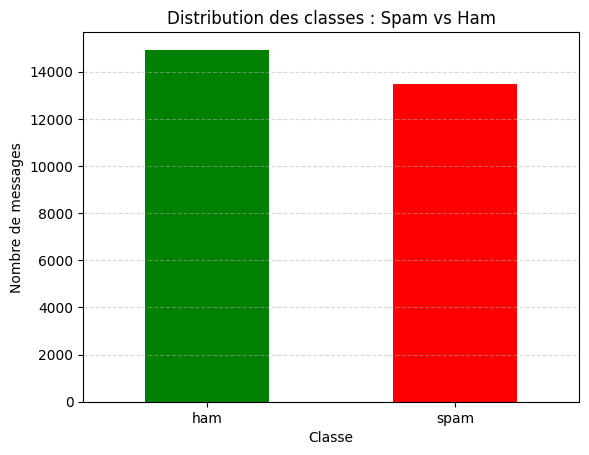

In [256]:
import matplotlib.pyplot as plt

# Affichage sous forme d'histogramme
counts.plot(kind='bar', color=['green', 'red'])

plt.title('Distribution des classes : Spam vs Ham')
plt.xlabel('Classe')
plt.ylabel('Nombre de messages')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


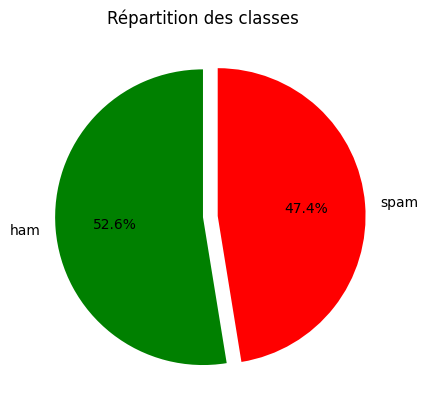

In [257]:
# Camembert
counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'], startangle=90, explode=(0, 0.1))

plt.title('Répartition des classes')
plt.ylabel('')  # Supprimer le label par défaut
plt.show()


Créer des wordclouds pour les spams et les ham

In [258]:
from wordcloud import WordCloud

Séparer les textes Spam et Ham

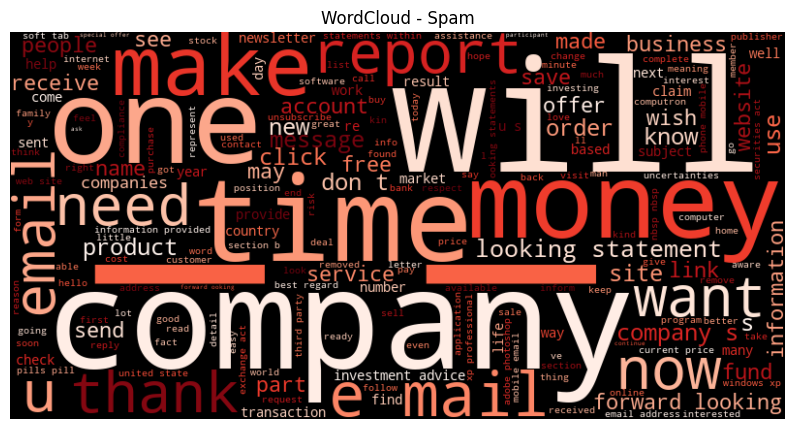

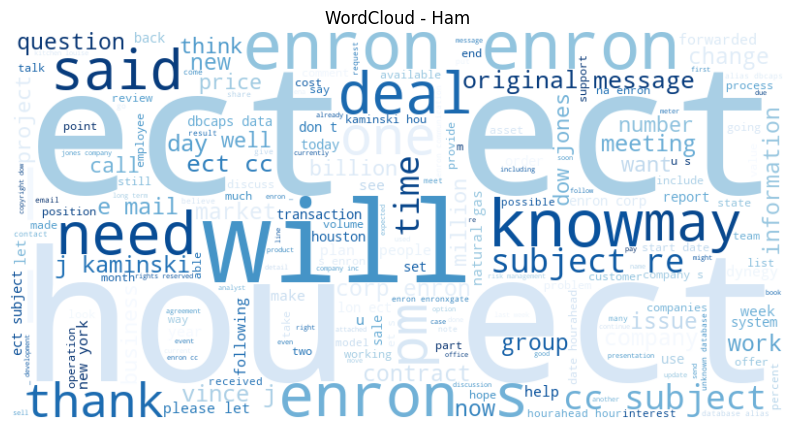

In [262]:
spam_text = " ".join(df[df['label_text'] == "spam"]['text'].astype(str))
ham_text = " ".join(df[df['label_text'] == "ham"]['text'].astype(str))

plt.figure(figsize=(10,6))
wc_spam = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_text)
plt.imshow(wc_spam, interpolation='bilinear'); 
plt.axis("off"); 
plt.title("WordCloud - Spam")
plt.show()

plt.figure(figsize=(10,6))
wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(ham_text)
plt.imshow(wc_ham, interpolation='bilinear'); 
plt.axis("off"); 
plt.title("WordCloud - Ham")
plt.show()

Longueur moyenne en caractères

In [263]:
# Ajouter une colonne 'length' contenant la longueur de chaque message
df['length'] = df['text'].astype(str).apply(len)

# Longueur moyenne
mean_length = df['length'].mean()
print(f"Longueur moyenne des messages (caractères) : {mean_length:.2f}")


Longueur moyenne des messages (caractères) : 1494.77


Suppression de la ponctuation et des caractères spéciaux

In [265]:
import re

# Fonction de nettoyage
def nettoyer_ponctuation(text):
    # Supprimer tout sauf les lettres et les espaces
    return re.sub(r'[^a-zA-Z\s]', '', text)

# Appliquer à la colonne 'text'
df['text'] = df['text'].astype(str).apply(nettoyer_ponctuation)
df.head()

,text,label,label_text,subject,message,date,text_length,length
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156,156
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112,1112
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242,242
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127,127
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329,329
